In [1]:
import pandas as pd # process and manipulate table data, implementing operations such as loading, aligning, merging, and transforming datasets efficiently
import numpy as np # numerical computing library for working with arrays and matrices, providing mathematical functions to operate on these data structures
import matplotlib.pyplot as plt # plotting library for creating static, animated, and interactive visualizations in Python
import os   # operating system interfaces for file and directory manipulation
import warnings # warning control to suppress or manage warning messages

from tkinter import Tk # standard GUI library for Python, used here to create file dialog windows
from tkinter.filedialog import askopenfilenames # function to open file dialog for selecting multiple files

# Suppress pandas parsing warnings
warnings.filterwarnings('ignore', message="Could not infer format") 

Loading and processing rainfall data...
  CORMP: 2125 hourly records
  Davis: 2127 hourly records
  OWLR_CMS: 2580 hourly records

Filtering to period: 2025-12-19 09:00:00 to 2026-03-17 09:00:00
  CORMP (filtered): 2113 records
  Davis (filtered): 2113 records
  OWLR_CMS (filtered): 2511 records


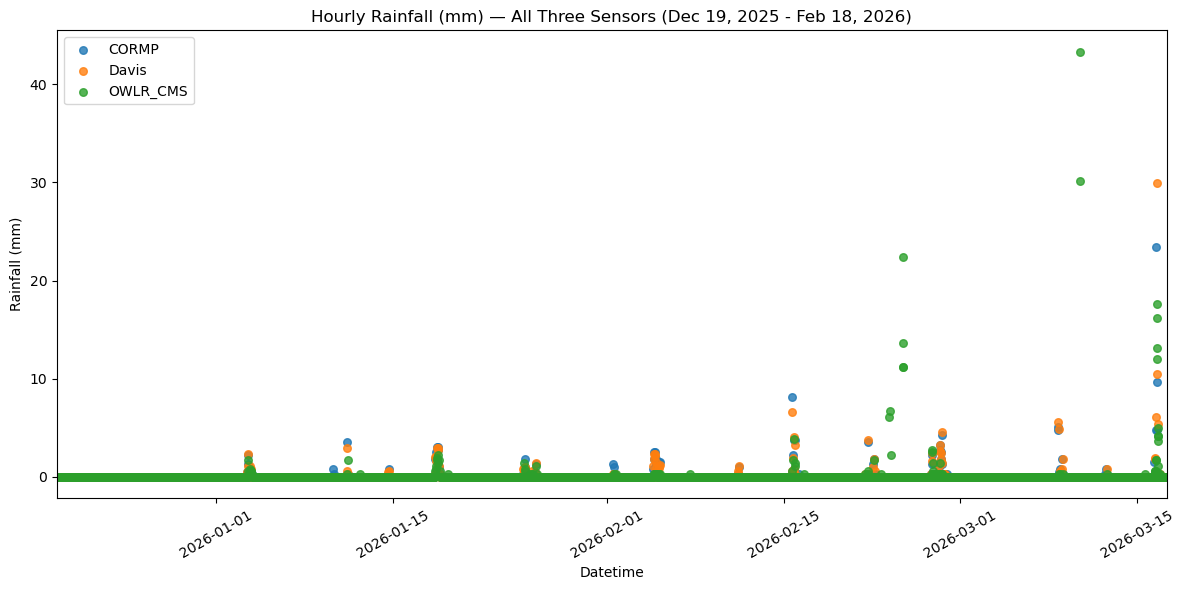

In [2]:
# STEP 1: Define file paths and helper functions
# Earliest data from OWLR_CMS is Dec 19, 2025, therefore all graphs begin at this time stamp.
file_1 = "Data/precip_CORMP_03172026.csv"   # needs hourly sum
file_2 = "Data/precip_Davis_03172026.csv"   # needs hourly sum
file_3 = "Data/OWLR_CMS_03172026.csv"   # already hourly

import io # for in-memory file operations
import re # for regular expressions

# detects header row by looking for keywords in the first max_lines (200) lines
# looking for for keywords like 'date' or 'time', combined with a comma (typical CSV header indicator).
def detect_header_row(path, max_lines=200):
    with open(path, 'r', encoding='utf-8', errors='ignore') as fh:
        for i, line in enumerate(fh):
            if i >= max_lines:
                break
            low = line.lower()
            # looking for header lines usually contain 'date' or 'time' and a comma
            if (('date' in low or 'time' in low) and ',' in line) or ('date &' in low):
                return i
    return 0


# Load and process rainfall_0 CSV file with "smart column detection". Returns data from datetime and rainfall 
# Converts units if needed, and resamples to hourly aggregates.
def load_and_process(filepath, assume_inches=False, already_hourly=False, parse_embedded_string=False):
    path = os.path.join(filepath)
    
    # Special handling for rainfall_0000 format: use header=None to preserve comma-separated string values
    if parse_embedded_string:
        df = pd.read_csv(path, header=None, engine='python')
        # Assign column names for embedded string format
        df.columns = ['Device_ID', 'Datetime', 'Sensor', 'Event', 'Data']
        dtcol = 'Datetime'
        rcol = 'Data'
    else:
        header_row = detect_header_row(path, max_lines=200)
        try:
            # set header to detected row; also skip percent-comment lines
            df = pd.read_csv(path, header=header_row, comment='%', engine='python')
        except Exception as e:
            print(f"read_csv failed for {path}: {e}")
            df = pd.read_csv(path, engine='python', sep=None, on_bad_lines='warn')

        # ensure column names are strings
        df.columns = [str(c) for c in df.columns]

        # find datetime column by keywords or by attempting to parse columns
        datetime_cols = [c for c in df.columns if any(k in c.lower() for k in ('date','time','datetime','timestamp'))]
        dtcol = None
        if datetime_cols: # found by keyword
            dtcol = datetime_cols[0]
        else:
            for c in df.columns:
                try:
                    parsed = pd.to_datetime(df[c], errors='coerce') # try to parse as datetime
                    if parsed.notna().sum() > 0: # at least some valid datetimes
                        dtcol = c
                        break
                except Exception:
                    continue
        if dtcol is None:
            raise ValueError(f"No datetime-like column found in {filepath}")

        # find rainfall column
        rain_cols = [c for c in df.columns if any(k in c.lower() for k in ('rain','precip','mm','inches'))]
        if rain_cols:
            rcol = rain_cols[0]
        else:
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            rcol = numeric_cols[0] if numeric_cols else None

        if rcol is None:
            for c in df.columns:
                coerced = pd.to_numeric(df[c], errors='coerce')
                if coerced.notna().sum() > 0:
                    rcol = c
                    df[c] = coerced
                    break
        if rcol is None:
            raise ValueError(f"No rainfall/numeric column found in {filepath}")

    df['datetime'] = pd.to_datetime(df[dtcol], errors='coerce')

    # Special handling for rainfall_0000 format: extract rainfall value from comma-separated string (3rd value)
    if parse_embedded_string:
        def extract_rain_value(val):
            try:
                if pd.isna(val):
                    return np.nan
                val_str = str(val).strip().strip('"')  # remove quotes if present
                parts = [p.strip() for p in val_str.split(',')]
                if len(parts) > 2:
                    return float(parts[2])  # 3rd value (index 2) is rainfall in mm
                else:
                    return np.nan
            except:
                return np.nan
        df['rain_mm'] = df[rcol].apply(extract_rain_value)
        rcol = 'rain_mm'
    else:
        df[rcol] = pd.to_numeric(df[rcol], errors='coerce')
        if assume_inches:
            df[rcol] = df[rcol] * 25.4

    subset_cols = [c for c in ['datetime', rcol] if c in df.columns]
    df = df.dropna(subset=subset_cols)

    if 'datetime' in df.columns:
        df = df.set_index('datetime')
    else:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise KeyError('datetime')

    if already_hourly:
        hourly = df.reset_index().rename(columns={rcol: 'rain_mm'})
        if 'datetime' not in hourly.columns:
            hourly = hourly.rename(columns={hourly.columns[0]: 'datetime'})
    else:
        hourly = df[rcol].resample('h').sum().reset_index().rename(columns={rcol: 'rain_mm'})
    return hourly


# STEP 2: Load and process all three rainfall files

print("Loading and processing rainfall data...")
cormp = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0 = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

print(f"  CORMP: {len(cormp)} hourly records")
print(f"  Davis: {len(davis)} hourly records")
print(f"  OWLR_CMS: {len(rain0)} hourly records")


# STEP 3: Filter to the analysis date range (Dec 19, 2025 - Jan 6, 2026)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-03-17 09:00')

print(f"\nFiltering to period: {start} to {end}")

cormp = cormp[(cormp['datetime'] >= start) & (cormp['datetime'] <= end)].reset_index(drop=True)
davis = davis[(davis['datetime'] >= start) & (davis['datetime'] <= end)].reset_index(drop=True)
rain0 = rain0[(rain0['datetime'] >= start) & (rain0['datetime'] <= end)].reset_index(drop=True)

print(f"  CORMP (filtered): {len(cormp)} records")
print(f"  Davis (filtered): {len(davis)} records")
print(f"  OWLR_CMS (filtered): {len(rain0)} records")

# STEP 4: Plot - All three sensors over full date range

plt.figure(figsize=(12,6))
if not cormp.empty:
    plt.scatter(cormp['datetime'], cormp['rain_mm'], label='CORMP', s=30, alpha=0.8)
if not davis.empty:
    plt.scatter(davis['datetime'], davis['rain_mm'], label='Davis', s=30, alpha=0.8)
if not rain0.empty:
    plt.scatter(rain0['datetime'], rain0['rain_mm'], label='OWLR_CMS', s=30, alpha=0.8)

plt.xlabel('Datetime')
plt.ylabel('Rainfall (mm)')
plt.title('Hourly Rainfall (mm) — All Three Sensors (Dec 19, 2025 - Feb 18, 2026)')
plt.legend()
plt.xlim(start, end)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


FULL PERIOD ANALYSIS: CORMP vs Davis vs OWLR_CMS
December 19th, 2025 - March 17th, 2026

Data summary:
  CORMP records: 2113
  Davis records: 2113
  OWLR_CMS records: 2511

Merged dataset shape: (2522, 9)

CORP vs Davis:
  Pearson Correlation: 0.6137
  R²: 0.3767
  Slope: 0.7375
  MAPE: 60.01%

CORP vs OWLR_CMS:
  Pearson Correlation: 0.1710
  R²: 0.0292
  Slope: 0.2841
  MAPE: 109.67%

Generating scatter plot...
  Plotted 2522 CORMP data points
  Plotted 2522 Davis data points
  Plotted 2511 OWLR_CMS data points


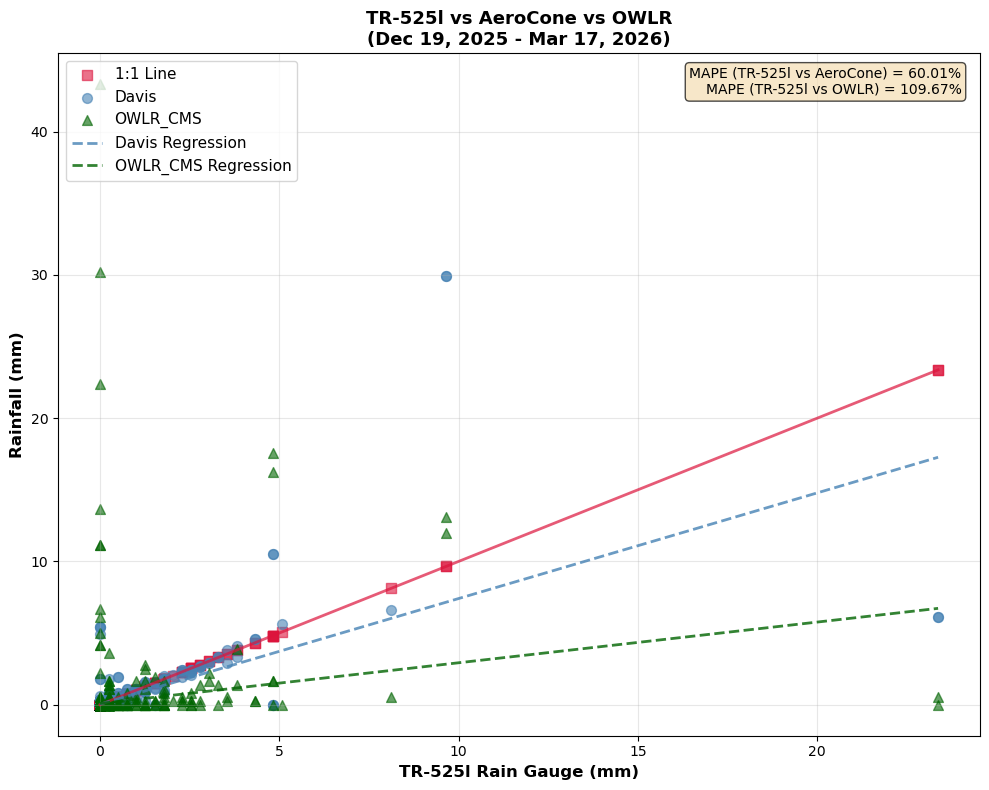

In [4]:
# CORMP (X-axis) vs Davis and OWLR_CMS (Y-axis) — Full Period Comparison
# December 19th, 2025 - March 17th, 2026

print("=" * 70)
print("FULL PERIOD ANALYSIS: CORMP vs Davis vs OWLR_CMS")
print("December 19th, 2025 - March 17th, 2026")
print("=" * 70)

# Use the already-filtered datasets from the initial load
print(f"\nData summary:")
print(f"  CORMP records: {len(cormp)}")
print(f"  Davis records: {len(davis)}")
print(f"  OWLR_CMS records: {len(rain0)}")

# Round all to nearest HOUR for alignment
cormp_full = cormp.copy()
davis_full = davis.copy()
rain0_full = rain0.copy()

cormp_full['datetime'] = cormp_full['datetime'].dt.floor('h')
davis_full['datetime'] = davis_full['datetime'].dt.floor('h')
rain0_full['datetime'] = rain0_full['datetime'].dt.floor('h')

# Merge datasets on datetime
merged_full = pd.merge(cormp_full, davis_full, on='datetime', how='outer', suffixes=('_cormp','_davis'))
merged_full = pd.merge(merged_full, rain0_full, on='datetime', how='outer')
merged_full = merged_full.rename(columns={'rain_mm': 'rain_mm_owlr_cms'})

print(f"\nMerged dataset shape: {merged_full.shape}")

# Compute correlations, statistics, and MAPEs
mape_cd = float('nan')
mape_co = float('nan')

if not merged_full.empty:
    from scipy import stats
    
    # CORMP vs Davis
    cormp_davis_data = merged_full[merged_full['rain_mm_cormp'].notna() & merged_full['rain_mm_davis'].notna()]
    if not cormp_davis_data.empty:
        corr_cd = cormp_davis_data['rain_mm_cormp'].corr(cormp_davis_data['rain_mm_davis'])
        r2_cd = corr_cd**2
        slope_cd, intercept_cd, _, _, _ = stats.linregress(cormp_davis_data['rain_mm_cormp'], cormp_davis_data['rain_mm_davis'])

        # MAPE (CORMP as reference)
        mape_mask_cd = cormp_davis_data['rain_mm_cormp'] != 0
        if mape_mask_cd.any():
            mape_cd = np.mean(
                np.abs(
                    (cormp_davis_data.loc[mape_mask_cd, 'rain_mm_cormp'] - cormp_davis_data.loc[mape_mask_cd, 'rain_mm_davis'])
                    / cormp_davis_data.loc[mape_mask_cd, 'rain_mm_cormp']
                )
            ) * 100

        print(f"\nCORP vs Davis:")
        print(f"  Pearson Correlation: {corr_cd:.4f}")
        print(f"  R²: {r2_cd:.4f}")
        print(f"  Slope: {slope_cd:.4f}")
        if pd.notna(mape_cd):
            print(f"  MAPE: {mape_cd:.2f}%")
        else:
            print("  MAPE: undefined")
    
    # CORMP vs OWLR_CMS
    cormp_rain0_data = merged_full[merged_full['rain_mm_cormp'].notna() & merged_full['rain_mm_owlr_cms'].notna()]
    if not cormp_rain0_data.empty:
        corr_cr = cormp_rain0_data['rain_mm_cormp'].corr(cormp_rain0_data['rain_mm_owlr_cms'])
        r2_cr = corr_cr**2
        slope_cr, intercept_cr, _, _, _ = stats.linregress(cormp_rain0_data['rain_mm_cormp'], cormp_rain0_data['rain_mm_owlr_cms'])

        # MAPE (CORMP as reference)
        mape_mask_co = cormp_rain0_data['rain_mm_cormp'] != 0
        if mape_mask_co.any():
            mape_co = np.mean(
                np.abs(
                    (cormp_rain0_data.loc[mape_mask_co, 'rain_mm_cormp'] - cormp_rain0_data.loc[mape_mask_co, 'rain_mm_owlr_cms'])
                    / cormp_rain0_data.loc[mape_mask_co, 'rain_mm_cormp']
                )
            ) * 100

        print(f"\nCORP vs OWLR_CMS:")
        print(f"  Pearson Correlation: {corr_cr:.4f}")
        print(f"  R²: {r2_cr:.4f}")
        print(f"  Slope: {slope_cr:.4f}")
        if pd.notna(mape_co):
            print(f"  MAPE: {mape_co:.2f}%")
        else:
            print("  MAPE: undefined")

# Create scatter plot: CORMP (X-axis) vs Davis and OWLR_CMS (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_full.empty:
    # Plot CORMP data (1:1 line)
    cormp_data = merged_full[merged_full['rain_mm_cormp'].notna()]
    if not cormp_data.empty:
        plt.scatter(cormp_data['rain_mm_cormp'], cormp_data['rain_mm_cormp'], 
                   s=50, alpha=0.6, color='crimson', label='1:1 Line', marker='s')
        # Draw line through CORMP data
        cormp_sorted = cormp_data.sort_values('rain_mm_cormp')
        plt.plot(cormp_sorted['rain_mm_cormp'], cormp_sorted['rain_mm_cormp'], 
                color='crimson', linewidth=2, alpha=0.7)
        print(f"  Plotted {len(cormp_data)} CORMP data points")
    
    # Plot Davis data
    davis_data = merged_full[merged_full['rain_mm_davis'].notna()]
    if not davis_data.empty:
        plt.scatter(davis_data['rain_mm_cormp'], davis_data['rain_mm_davis'], 
                   s=50, alpha=0.6, color='steelblue', label='Davis', marker='o')
        print(f"  Plotted {len(davis_data)} Davis data points")
    
    # Plot OWLR_CMS data
    owlr_cms_data = merged_full[merged_full['rain_mm_owlr_cms'].notna()]
    if not owlr_cms_data.empty:
        plt.scatter(owlr_cms_data['rain_mm_cormp'], owlr_cms_data['rain_mm_owlr_cms'], 
                   s=50, alpha=0.6, color='darkgreen', label='OWLR_CMS', marker='^')
        print(f"  Plotted {len(owlr_cms_data)} OWLR_CMS data points")
    
    # Add linear regression lines
    # Get x-axis range for regression line plotting
    all_x = []
    if not cormp_data.empty:
        all_x.extend(cormp_data['rain_mm_cormp'].values)
    if not davis_data.empty:
        all_x.extend(davis_data['rain_mm_cormp'].values)
    if not owlr_cms_data.empty:
        all_x.extend(owlr_cms_data['rain_mm_cormp'].values)
    
    if all_x:
        x_min, x_max = min(all_x), max(all_x)
        x_line = np.array([x_min, x_max])
        
        # Davis regression line
        if not cormp_davis_data.empty:
            y_davis = slope_cd * x_line + intercept_cd
            plt.plot(x_line, y_davis, color='steelblue', linewidth=2, alpha=0.8, linestyle='--', label='Davis Regression')
        
        # OWLR_CMS regression line
        if not cormp_rain0_data.empty:
            y_rain0 = slope_cr * x_line + intercept_cr
            plt.plot(x_line, y_rain0, color='darkgreen', linewidth=2, alpha=0.8, linestyle='--', label='OWLR_CMS Regression')

plt.xlabel('TR-525l Rain Gauge (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('TR-525l vs AeroCone vs OWLR\n(Dec 19, 2025 - Mar 17, 2026)', fontsize=13, fontweight='bold')

# Add MAPE annotation to plot
ax = plt.gca()
mape_cd_text = f"MAPE (TR-525l vs AeroCone) = {mape_cd:.2f}%" if pd.notna(mape_cd) else "MAPE (TR-525l vs AeroCone) = undefined"
mape_co_text = f"MAPE (TR-525l vs OWLR) = {mape_co:.2f}%" if pd.notna(mape_co) else "MAPE (TR-525l vs OWLR_CMS) = undefined"
ax.text(
    0.98, 0.98,
    f"{mape_cd_text}\n{mape_co_text}",
    transform=ax.transAxes,
    fontsize=10,
    va='top',
    ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
)

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


FULL PERIOD ANALYSIS: CORMP vs OWLR_CMS Only
December 19th, 2025 - February 18th, 2026

Data summary:
  CORMP records: 2113
  OWLR_CMS records: 2511

Merged dataset shape: (2522, 8)

CORMP vs OWLR_CMS:
  Pearson Correlation: 0.1710
  R²: 0.0292
  Slope: 0.2841

Generating scatter plot...
  Plotted 2522 CORMP data points
  Plotted 2511 OWLR_CMS data points


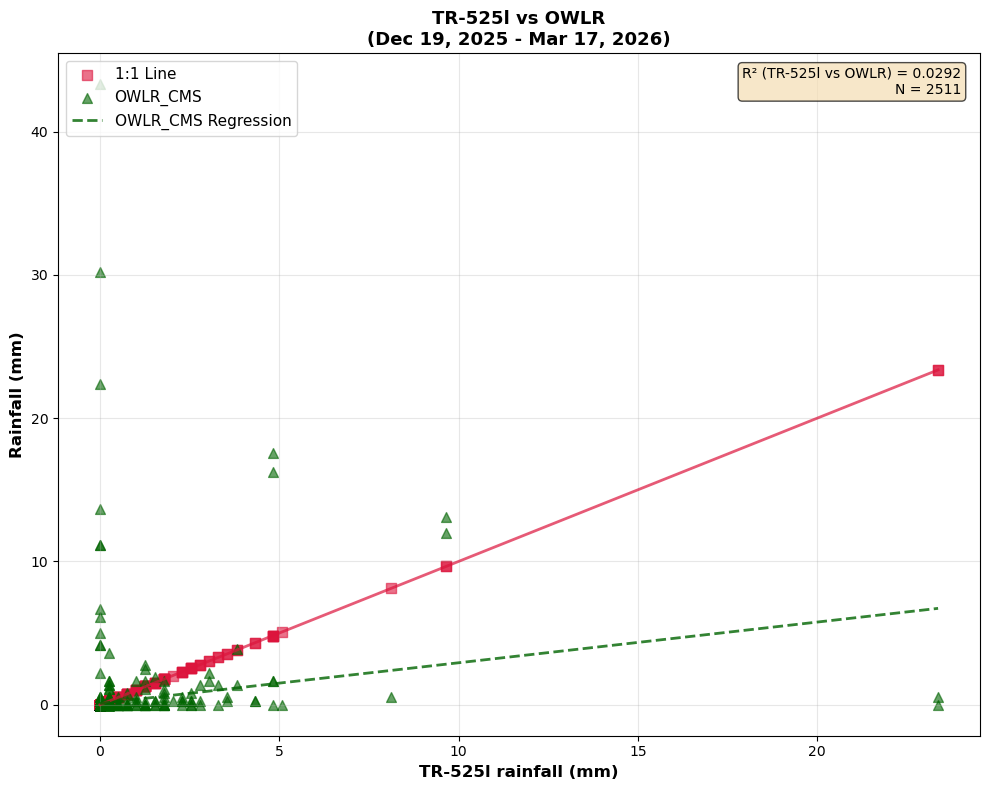

In [6]:
# CORMP (X-axis) vs OWLR_CMS (Y-axis) — Full Period Comparison
# December 19th, 2025 - February 18th, 2026

print("=" * 70)
print("FULL PERIOD ANALYSIS: CORMP vs OWLR_CMS Only")
print("December 19th, 2025 - February 18th, 2026")
print("=" * 70)

# Use the already-filtered datasets from the initial load
print(f"\nData summary:")
print(f"  CORMP records: {len(cormp)}")
print(f"  OWLR_CMS records: {len(rain0)}")

# Round all to nearest HOUR for alignment
cormp_full_rain0 = cormp.copy()
rain0_full_only = rain0.copy()

cormp_full_rain0['datetime'] = cormp_full_rain0['datetime'].dt.floor('h')
rain0_full_only['datetime'] = rain0_full_only['datetime'].dt.floor('h')

# Merge datasets on datetime
merged_rain0_only = pd.merge(cormp_full_rain0, rain0_full_only, on='datetime', how='outer', suffixes=('_cormp','_owlr_cms'))

print(f"\nMerged dataset shape: {merged_rain0_only.shape}")

# Compute correlations and statistics
r2_co_only = float('nan')
if not merged_rain0_only.empty:
    from scipy import stats
    
    # CORMP vs OWLR_CMS
    cormp_owlr_cms_data_only = merged_rain0_only[merged_rain0_only['rain_mm_cormp'].notna() & merged_rain0_only['rain_mm_owlr_cms'].notna()]
    if not cormp_owlr_cms_data_only.empty:
        corr_co_only = cormp_owlr_cms_data_only['rain_mm_cormp'].corr(cormp_owlr_cms_data_only['rain_mm_owlr_cms'])
        r2_co_only = corr_co_only**2
        slope_co_only, intercept_co_only, _, _, _ = stats.linregress(cormp_owlr_cms_data_only['rain_mm_cormp'], cormp_owlr_cms_data_only['rain_mm_owlr_cms'])
        print(f"\nCORMP vs OWLR_CMS:")
        print(f"  Pearson Correlation: {corr_co_only:.4f}")
        print(f"  R²: {r2_co_only:.4f}")
        print(f"  Slope: {slope_co_only:.4f}")

# Create scatter plot: CORMP (X-axis) vs OWLR_CMS (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_rain0_only.empty:
    # Plot CORMP data (1:1 line)
    cormp_data_rain0 = merged_rain0_only[merged_rain0_only['rain_mm_cormp'].notna()]
    if not cormp_data_rain0.empty:
        plt.scatter(cormp_data_rain0['rain_mm_cormp'], cormp_data_rain0['rain_mm_cormp'], 
                   s=50, alpha=0.6, color='crimson', label='1:1 Line', marker='s')
        # Draw line through CORMP data
        cormp_sorted_rain0 = cormp_data_rain0.sort_values('rain_mm_cormp')
        plt.plot(cormp_sorted_rain0['rain_mm_cormp'], cormp_sorted_rain0['rain_mm_cormp'], 
                color='crimson', linewidth=2, alpha=0.7)
        print(f"  Plotted {len(cormp_data_rain0)} CORMP data points")
    
    # Plot OWLR_CMS data
    owlr_cms_data_only = merged_rain0_only[merged_rain0_only['rain_mm_owlr_cms'].notna()]
    if not owlr_cms_data_only.empty:
        plt.scatter(owlr_cms_data_only['rain_mm_cormp'], owlr_cms_data_only['rain_mm_owlr_cms'], 
                   s=50, alpha=0.6, color='darkgreen', label='OWLR_CMS', marker='^')
        print(f"  Plotted {len(owlr_cms_data_only)} OWLR_CMS data points")
    
    # Add linear regression line for OWLR_CMS
    all_x_owlr_cms = []
    if not cormp_data_rain0.empty:
        all_x_owlr_cms.extend(cormp_data_rain0['rain_mm_cormp'].values)
    if not owlr_cms_data_only.empty:
        all_x_owlr_cms.extend(owlr_cms_data_only['rain_mm_cormp'].values)
    
    if all_x_owlr_cms:
        x_min_owlr_cms, x_max_owlr_cms = min(all_x_owlr_cms), max(all_x_owlr_cms)
        x_line_owlr_cms = np.array([x_min_owlr_cms, x_max_owlr_cms])
        
        # OWLR_CMS regression line
        if not merged_rain0_only.empty:
            y_owlr_cms_only = slope_co_only * x_line_owlr_cms + intercept_co_only
            plt.plot(x_line_owlr_cms, y_owlr_cms_only, color='darkgreen', linewidth=2, alpha=0.8, linestyle='--', label='OWLR_CMS Regression')

# Add R2 annotation to plot
ax = plt.gca()
if pd.notna(r2_co_only):
    n_pairs = len(cormp_owlr_cms_data_only) if 'cormp_owlr_cms_data_only' in locals() else 0
    ax.text(
        0.98, 0.98,
        f"R² (TR-525l vs OWLR) = {r2_co_only:.4f}\nN = {n_pairs}",
        transform=ax.transAxes,
        fontsize=10,
        va='top',
        ha='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
    )

plt.xlabel('TR-525l rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('TR-525l vs OWLR\n(Dec 19, 2025 - Mar 17, 2026)', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ANALYSIS 3: precip_CORMP vs rainfall_0000 Comparison

Before datetime alignment:
  CORMP shape: (2113, 2)
  rainfall_0000 shape: (2511, 7)

After rounding to nearest hour:
  CORMP first 5 timestamps: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]
  rainfall_0000 first 5 timestamps: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]

Overlapping hourly timestamps: 2102 hours
Merged dataset shape: (2511, 8)

Pearson Correlation: 0.1710
R^2 (Coefficient of Determination): 0.0292
Correction factor (multiply rainfall_0000 by): 0.1030

Generating scatter plot...
  Plotted 2511 data points


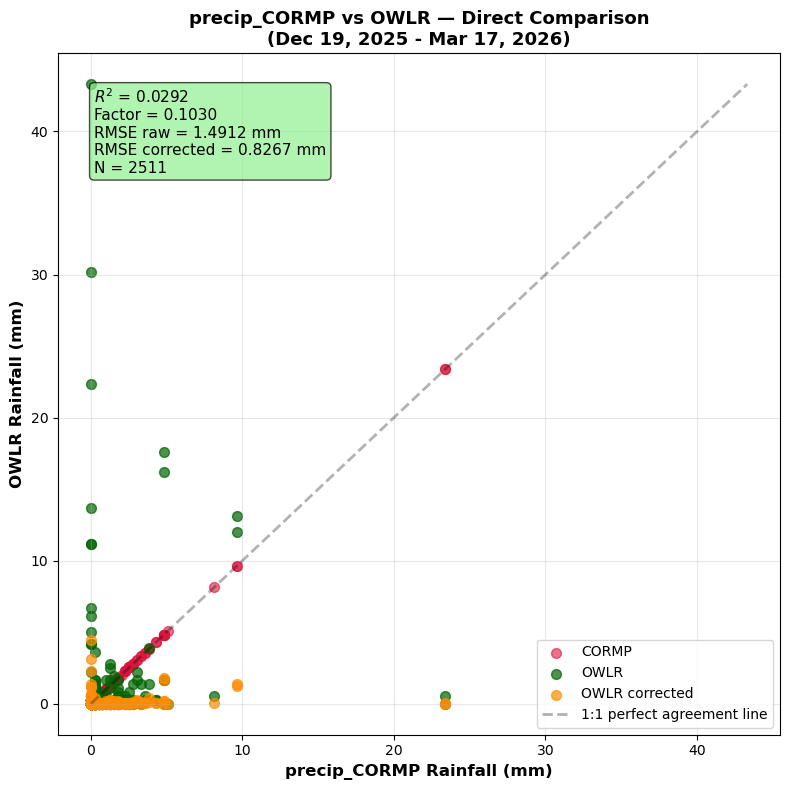

In [10]:
# precip_CORMP vs rainfall_0000 — Direct Sensor Comparison
# Merge datasets by datetime, compute correlation (R^2), and plot

print("=" * 70)
print("ANALYSIS 3: precip_CORMP vs rainfall_0000 Comparison")
print("=" * 70)

# Reload and process both datasets for clean analysis
cormp_only = load_and_process(file_1, assume_inches=True, already_hourly=False)
rain0_cormp = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-03-17 09:00')

cormp_only = cormp_only[(cormp_only['datetime'] >= start) & (cormp_only['datetime'] <= end)].reset_index(drop=True)
rain0_cormp = rain0_cormp[(rain0_cormp['datetime'] >= start) & (rain0_cormp['datetime'] <= end)].reset_index(drop=True)

print(f"\nBefore datetime alignment:")
print(f"  CORMP shape: {cormp_only.shape}")
print(f"  rainfall_0000 shape: {rain0_cormp.shape}")

# Round both to nearest HOUR to align hourly data (discard minutes and seconds)
cormp_only['datetime'] = cormp_only['datetime'].dt.floor('h')
rain0_cormp['datetime'] = rain0_cormp['datetime'].dt.floor('h')

print(f"\nAfter rounding to nearest hour:")
print(f"  CORMP first 5 timestamps: {cormp_only['datetime'].head().tolist()}")
print(f"  rainfall_0000 first 5 timestamps: {rain0_cormp['datetime'].head().tolist()}")

# Check for overlapping datetimes
cormp_dates = set(cormp_only['datetime'])
rain0_dates = set(rain0_cormp['datetime'])
overlap = cormp_dates.intersection(rain0_dates)
print(f"\nOverlapping hourly timestamps: {len(overlap)} hours")

# Align datasets on datetime for direct comparison
merged_cr_only = pd.merge(rain0_cormp, cormp_only, on='datetime', how='inner', suffixes=('_rain0','_cormp'))
print(f"Merged dataset shape: {merged_cr_only.shape}")

# Compute correlation, R^2, and correction factor
if not merged_cr_only.empty:
    from scipy import stats
    corr_cr = merged_cr_only['rain_mm_rain0'].corr(merged_cr_only['rain_mm_cormp'])
    r2_cr = corr_cr**2 if pd.notna(corr_cr) else float('nan')
    # Regression for correction factor: CORMP as reference (x = rain0, y = cormp)
    slope_corr, intercept_corr, _, _, _ = stats.linregress(
        merged_cr_only['rain_mm_rain0'], merged_cr_only['rain_mm_cormp']
    )
    print(f"\nPearson Correlation: {corr_cr:.4f}")
    print(f"R^2 (Coefficient of Determination): {r2_cr:.4f}")
    print(f"Correction factor (multiply rainfall_0000 by): {slope_corr:.4f}")
else:
    r2_cr = float('nan')
    slope_corr = float('nan')
    intercept_corr = float('nan')
    print("No overlapping data found!")

# Create scatter plot: precip_CORMP (X-axis) vs rainfall_0000 (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(8,8))
if not merged_cr_only.empty:
    # CORMP reference points (1:1)
    plt.scatter(merged_cr_only['rain_mm_cormp'], merged_cr_only['rain_mm_cormp'],
                s=50, alpha=0.6, color='crimson', label='CORMP')
    plt.scatter(merged_cr_only['rain_mm_cormp'], merged_cr_only['rain_mm_rain0'], s=50, alpha=0.7, color='darkgreen', label='OWLR')
    # Corrected OWLR using the correction factor
    corrected_rain0 = merged_cr_only['rain_mm_rain0'] * slope_corr
    plt.scatter(merged_cr_only['rain_mm_cormp'], corrected_rain0, s=50, alpha=0.7, color='darkorange', label='OWLR corrected')
    print(f"  Plotted {len(merged_cr_only)} data points")
else:
    print("  No data to plot - no overlapping datetimes found")

plt.xlabel('precip_CORMP Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('OWLR Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('precip_CORMP vs OWLR — Direct Comparison\n(Dec 19, 2025 - Mar 17, 2026)', fontsize=13, fontweight='bold')

# Annotate R^2 and correction error on plot
try:
    ax = plt.gca()
    if not merged_cr_only.empty and pd.notna(r2_cr):
        rmse_raw = np.sqrt(np.mean((merged_cr_only['rain_mm_rain0'] - merged_cr_only['rain_mm_cormp'])**2))
        rmse_corr = np.sqrt(np.mean((corrected_rain0 - merged_cr_only['rain_mm_cormp'])**2))
        ax.text(0.05, 0.95,
                f'$R^2$ = {r2_cr:.4f}\nFactor = {slope_corr:.4f}\nRMSE raw = {rmse_raw:.4f} mm\nRMSE corrected = {rmse_corr:.4f} mm\nN = {len(merged_cr_only)}',
                transform=ax.transAxes, fontsize=11, va='top',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
except Exception as e:
    print(f"Warning: Could not annotate plot: {e}")

if not merged_cr_only.empty:
    max_val = max(merged_cr_only['rain_mm_rain0'].max(), merged_cr_only['rain_mm_cormp'].max())
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=2, label='1:1 perfect agreement line')
    plt.legend(loc='lower right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()